In [1]:
import os
os.environ["JAX_PLATFORMS"] = 'cpu'
import jax.numpy as jnp
import jax 
import numpy as np
from utils import (collect_data,
                   torch_to_jax,
                   clip,
                   flatten_tokens_features,
                   depths,
                   reduce_list_half_preserve_extremes,
                   remove_syn_group_averages,
                   )
from geometry import normalized_L2_distance
from datapaths import * 
import matplotlib.pyplot as plt


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
min_token_length = 6
n_tokens = min_token_length
n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'sem'
avg_tokens = 0

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]


In [3]:
all_activations_A = collect_data(input_path_A, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )

qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:02<00:00, 10.01it/s]


all_hidden_states["layer_0"].shape=torch.Size([2018, 6, 3584])
importing took 0.05461113452911377 m


In [ ]:
space_index = 'A'
global_center_flag = 1
act_A = {}
centers = {}
global_centers = {}
layers_A = np.array([1,14,28],dtype=int) # reduce_list_half_preserve_extremes(np.arange(1,depths[model_name]+1,dtype=int))

for layer_A in layers_A:
    activations_A = all_activations_A[f"layer_{layer_A}"]
    act_A[str(layer_A)] = torch_to_jax(activations_A[:,-n_tokens:,:],precision)
    act_A[str(layer_A)] = clip(act_A[str(layer_A)]) 
    act_A[str(layer_A)] = flatten_tokens_features(act_A[str(layer_A)])
    if global_center_flag:
        global_centers[str(layer_A)] = jnp.mean(act_A[str(layer_A)],axis=0)
        act_A[str(layer_A)] = act_A[str(layer_A)] - jnp.broadcast_to(global_centers[str(layer_A)],act_A[str(layer_A)].shape)
    
    # syntax_centers
    centers_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_syn/modelA_qwen7b/modelB_qwen7b/match_var_matching/n_files_21/min_token_length_6/similarities/centers_syn/Nbits_0/n_tokens_{n_tokens}/avg_tokens_0/batch_shuffle_0/layer_A_{layer_A}/layer_B_{layer_A}/"
    centers[str(layer_A)] = jnp.array(np.load(os.path.join(centers_folder, f'syn_centers_{space_index}.npy'))).astype(jnp.float32) #(num_groups,E)
    
    if global_center_flag: # centering syntax centers...
        centers[str(layer_A)] = centers[str(layer_A)] - jnp.broadcast_to(global_centers[str(layer_A)],centers[str(layer_A)].shape)
    # all_indices = jnp.array(np.loadtxt(centers_folder + f'syn_all_indices.txt',dtype=int),dtype=jnp.int32)
    # all_counts = jnp.array(np.loadtxt(centers_folder + f'syn_all_counts.txt',dtype=int),dtype=jnp.int32)

print(f'{act_A[str(layer_A)].shape=}')
print(f'{centers[str(layer_A)].shape=}')

act_A[str(layer_A)].shape=(2018, 21504)
centers[str(layer_A)].shape=(96, 21504)


In [5]:
group_ids_path = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/all_group_ids_A.txt"
sem_ids_path = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/sem_ids.txt"
sem_ids = jnp.array(np.loadtxt(sem_ids_path,dtype=int),dtype=jnp.int32)
for layer in act_A:
  act_A[layer] = act_A[layer][sem_ids]

all_group_ids = jnp.array(np.loadtxt(group_ids_path).astype(int))[:act_A[str(layer_A)].shape[0]]  # (n_samples,)
unique_group_ids, unique_counts = jnp.unique(all_group_ids, return_counts=True)
print(f'in sample: {len(unique_group_ids)=}')
assert len(all_group_ids) == act_A[str(layer_A)].shape[0]

in sample: len(unique_group_ids)=96


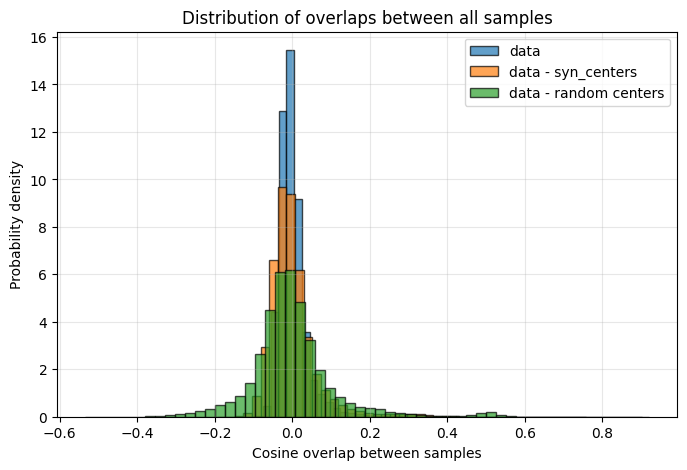

In [6]:
plt.figure(figsize=(8,5))
key = jax.random.PRNGKey(9999)  # Change seed for different permutations

center_flags = [0,1,-1]
removal_method = 'subtraction'
layer_A = 14

for center_flag in center_flags:

  if center_flag == 1:
    _all_group_ids = all_group_ids
    label = f'data - syn_centers '
  elif center_flag == -1:
    _all_group_ids = jax.random.permutation(key, all_group_ids)
    label = f'data - random centers'
  else:
    _all_group_ids = None
    label = f'data'

  
  X = act_A[str(layer_A)] / jnp.linalg.norm(act_A[str(layer_A)], axis=1, keepdims=True) # (n_samples, dim)

  if center_flag != 0:
    C = centers[str(layer_A)] / jnp.linalg.norm(centers[str(layer_A)], axis=1, keepdims=True)
    X = remove_syn_group_averages(X, C, _all_group_ids, removal_method)    
    X = X / jnp.linalg.norm(X, axis=1, keepdims=True)  

  # Compute pairwise overlaps
  similarity_matrix = X @ X.T  # shape: (n_samples, n_samples)

  # Extract upper triangular part (excluding diagonal) to avoid duplicates and self-overlaps
  triu_indices = jnp.triu_indices(similarity_matrix.shape[0], k=1)
  overlaps = similarity_matrix[triu_indices]

  # Plot histogram
  plt.hist(overlaps, bins=50, edgecolor='black', alpha=0.7, density=True, label=label)
plt.xlabel('Cosine overlap between samples')
plt.ylabel('Probability density')
plt.title('Distribution of overlaps between all samples')
plt.grid(True, alpha=0.3)
plt.legend()
# plt.yscale('log')
plt.show()


[0.9975323  0.99996024 0.99835956 ... 0.99991864 0.9980835  0.999668  ]
[0.99977684 0.9999978  0.9986415  ... 0.999123   0.99973994 0.9995447 ]
[0.9986312  0.9999975  0.9974538  ... 0.99961466 0.99987006 0.99815154]


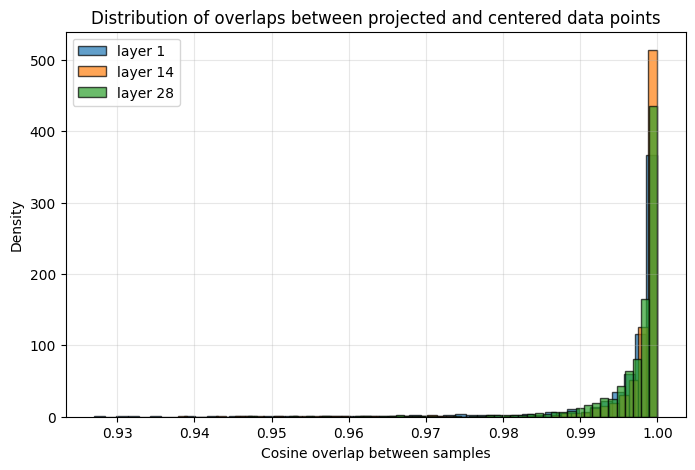

In [7]:
# plt.figure(figsize=(8,5))

# for layer_A in layers_A:
#     X = remove_syn_group_averages(act_A[str(layer_A)], centers[str(layer_A)], all_group_ids, 'projection')
#     X = X / jnp.linalg.norm(X, axis=1, keepdims=True)  # shape: (n_samples, dim)

#     Y = remove_syn_group_averages(act_A[str(layer_A)], centers[str(layer_A)], all_group_ids, 'subtraction')
#     Y = Y / jnp.linalg.norm(Y, axis=1, keepdims=True)  # shape: (n_samples, dim)

#     # Compute pairwise overlaps
#     similarity_matrix = X @ Y.T  # shape: (n_samples, n_samples)

#     # Extract upper triangular part (excluding diagonal) to avoid duplicates and self-overlaps
#     overlaps = similarity_matrix.diagonal()

#     # Plot histogram
#     plt.hist(overlaps, bins=50, edgecolor='black', alpha=0.7, density=True,label=f'layer {layer_A}')
#     print(overlaps)
# plt.xlabel('Cosine overlap between samples')
# plt.ylabel('Density')
# plt.title('Distribution of overlaps between projected and centered data points')
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.show()


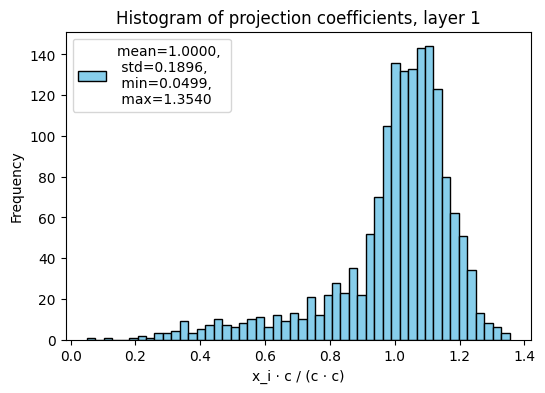

In [8]:
import matplotlib.pyplot as plt

layer = layers_A[0]  # just pick the last layer for example
act = act_A[str(layer)] / jnp.linalg.norm(act_A[str(layer)],axis=1,keepdims=True)         # shape (n_samples, T*E)
n_samples = act.shape[0]

# compute x_i · c / (c · c) for each group
ratios = []

for group_index in range(centers[str(layer)].shape[0]):
    indices = jnp.where(all_group_ids == group_index)[0]
    if len(indices) == 0:
        continue
    x_group = act[indices]           # (n_group_samples, T*E)
    c = x_group.mean(axis=0)
    ratio_group = (x_group @ c) / (c @ c)  # (n_group_samples,)
    ratios.append(ratio_group)
    # print(f'{group_index=}, {x_group.shape[0]=}')

ratios = jnp.concatenate(ratios)

# plot histogram
plt.figure(figsize=(6,4))
plt.hist(ratios, 
         bins=50, 
         color='skyblue', 
         edgecolor='black',
         label=f"mean={ratios.mean():.4f}, \n std={ratios.std():.4f}, \n min={ratios.min():.4f}, \n max={ratios.max():.4f}")
plt.xlabel("x_i · c / (c · c)")
plt.ylabel("Frequency")
plt.title(f"Histogram of projection coefficients, layer {layer}")
plt.legend()
plt.show()

# optionally print statistics


overlaps.mean()=Array(-0.002078, dtype=float32)
overlaps.mean()=Array(-0.00271089, dtype=float32)
overlaps.mean()=Array(-0.0026964, dtype=float32)


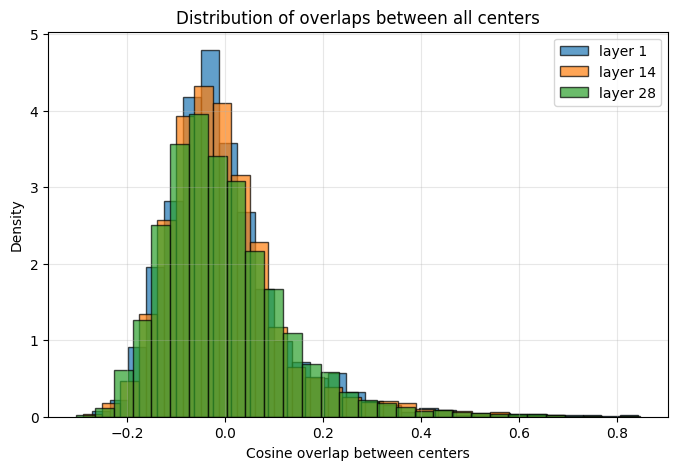

In [9]:
import itertools

plt.figure(figsize=(8,5))

for layer_A in layers_A:

  # Normalize all centers
  normed_centers = centers[str(layer_A)] / jnp.linalg.norm(centers[str(layer_A)], axis=1, keepdims=True)  # shape: (n_centers, dim)

  # Compute all pairwise overlaps (excluding self-overlaps)
  n_centers = normed_centers.shape[0]
  overlaps = []
  for i, j in itertools.combinations(range(n_centers), 2):
      overlaps.append(jnp.dot(normed_centers[i], normed_centers[j]))
  overlaps = jnp.array(overlaps)
  print(f'{overlaps.mean()=}')

  # Plot histogram
  plt.hist(overlaps, bins=30, edgecolor='black', alpha=0.7, density=True, label=f'layer {layer_A}')
plt.xlabel('Cosine overlap between centers')
plt.ylabel('Density')
plt.title('Distribution of overlaps between all centers')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


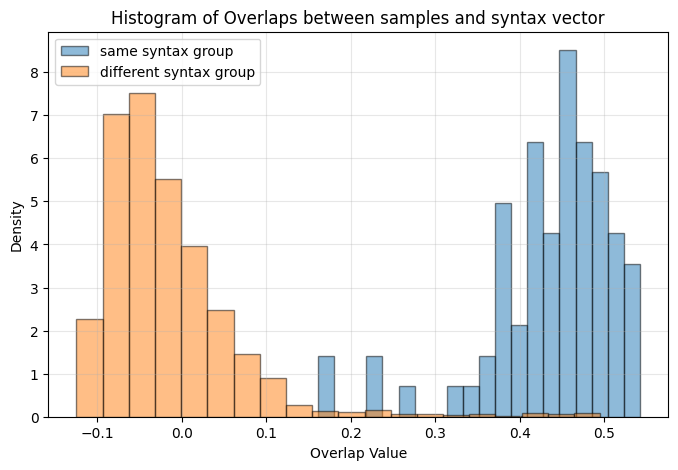

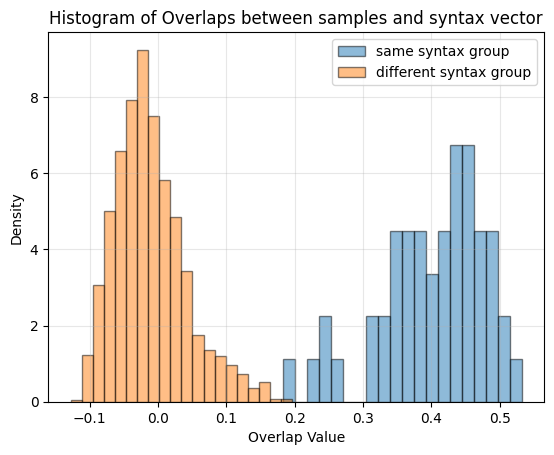

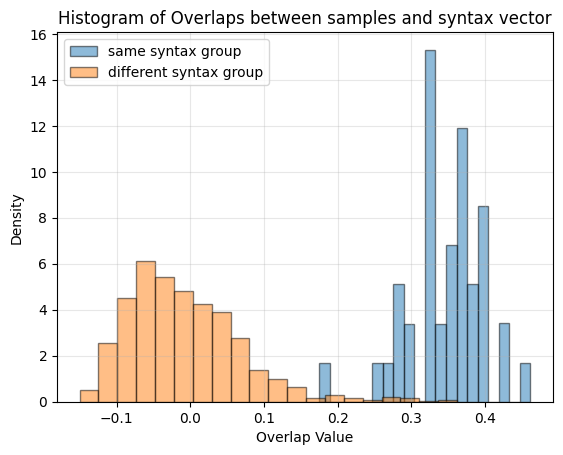

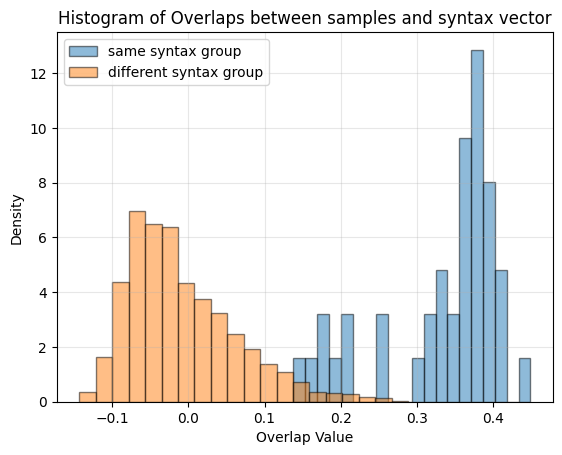

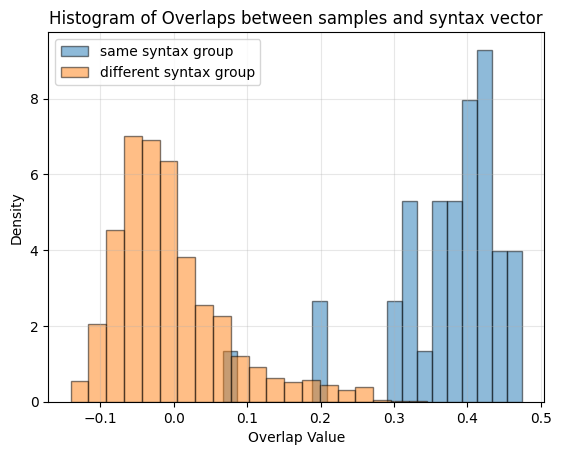

In [10]:
k = 5

for layer_A in [28]:
  plt.figure(figsize=(8, 5))
  colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
  topk_unique_indices = jnp.argsort(unique_counts)[-k:][::-1]  # top k indices by count, descending
  bins = 20

  for group_index_0 in topk_unique_indices:
      group_id = unique_group_ids[group_index_0]
      center = centers[str(layer_A)][group_id]

      group_indices = jnp.where(all_group_ids == group_id)[0]
      assert len(group_indices) == unique_counts[group_index_0]
      all_indices = jnp.arange(len(all_group_ids), dtype=jnp.int32)
      complementary_indices = all_indices[~jnp.isin(all_indices, group_indices)]

      for plot_id, indices in enumerate([group_indices, complementary_indices]):

          overlaps = jnp.zeros(shape=(len(indices),))
          for enum_i,i in enumerate(indices):
              overlaps = overlaps.at[enum_i].set(
                  jnp.dot(act_A[str(layer_A)][i] / jnp.linalg.norm(act_A[str(layer_A)][i]),
                          center / jnp.linalg.norm(center))
              )

          if len(indices) == len(group_indices):
              label = f'same syntax group'
          elif len(indices) == len(complementary_indices):
              label = 'different syntax group'

          plt.hist(overlaps,
                  bins=bins,
                  color=colors[plot_id],
                  edgecolor='black',
                  alpha=0.5,
                  density=True,
                  label=label)

      plt.title('Histogram of Overlaps between samples and syntax vector')
      plt.xlabel('Overlap Value')
      plt.ylabel('Density')
      plt.legend()
      plt.grid(True, alpha=0.3)
      plt.show()


In [11]:
### Sanity check on orderings: 
# top-k groups
k = 5
topk_unique_indices = jnp.argsort(unique_counts)[-k:][::-1]  # indices into unique_group_ids

for group_index_0 in topk_unique_indices:
    group_id = unique_group_ids[group_index_0]

    # indices of samples in this group
    group_indices = jnp.where(all_group_ids == group_id)[0]

    # compute average of samples in this group
    avg_vector = jnp.mean(act_A[str(layer_A)][group_indices], axis=0)

    # normalize both vectors
    avg_vector_norm = avg_vector / jnp.linalg.norm(avg_vector)
    center_norm = centers[str(layer_A)][group_id] / jnp.linalg.norm(centers[str(layer_A)][group_id])

    # compute overlap (cosine similarity)
    overlap = jnp.dot(avg_vector_norm, center_norm)

    print(f'Group {group_id}: average overlap with center = {overlap:.4f}')


Group 59: average overlap with center = 0.9975
Group 87: average overlap with center = 0.9853
Group 64: average overlap with center = 0.9938
Group 4: average overlap with center = 0.9792
Group 58: average overlap with center = 0.9973


In [12]:
k = 1
layer_A = 14
plt.figure(figsize=(8, 5))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

group_ids_path = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/group_ids.txt"
all_group_ids = jnp.array(np.loadtxt(group_ids_path).astype(int))[:act_A[str(layer_A)].shape[0]] # (n_samples,)
unique_group_ids,unique_counts = jnp.unique(all_group_ids,return_counts=True)
print(f'in sample: {len(unique_group_ids)=}')
assert len(all_group_ids) == act_A[str(layer_A)].shape[0]

topk_unique_indices = jnp.argsort(unique_counts)[-k:][::-1]  # top k indices by count, descending

for group_index_0 in topk_unique_indices:
    center = centers[str(layer_A)][unique_group_ids[group_index_0]]

    group_indices = jnp.where(all_group_ids==unique_group_ids[group_index_0])[0]
    assert len(group_indices) == unique_counts[group_index_0]
    all_indices = jnp.arange(len(all_group_ids),dtype=jnp.int32)
    complementary_indices = all_indices[~jnp.isin(all_indices,group_indices)]

    for plot_id,indices in enumerate([group_indices,complementary_indices]):
        
        overlaps = jnp.zeros(shape=(len(indices),))
        for enum_i,i in enumerate(indices):
            overlaps = overlaps.at[enum_i].set(
                jnp.dot(act_A[str(layer_A)][i] / jnp.linalg.norm(act_A[str(layer_A)][i]),
                        center / jnp.linalg.norm(center))
            )
            # overlaps = overlaps.at[i].set(normalized_L2_distance(act_A[str(layer_A)][i],center) )

        # --- empirical CDF ---
        sorted_vals = jnp.sort(overlaps)
        ecdf = jnp.arange(1, len(sorted_vals)+1) / len(sorted_vals)

        if len(indices) == len(group_indices):
            label = 'correct syntax group'
        elif len(indices) == len(complementary_indices):
            label = 'random syntax group'

        plt.plot(sorted_vals, ecdf,
                color=colors[plot_id], 
                label=label, 
                linewidth=2)

    plt.title('Empirical CDF of Overlaps between samples and syntax vector S')
    plt.xlabel('Overlap Value')
    plt.ylabel('Empirical CDF')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


FileNotFoundError: /home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/group_ids.txt not found.

<Figure size 800x500 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_samples = 1000
for dim in [5,15,150,1500,15000]:
  # 1. Generate 100 random vectors (Gaussian)
  X = np.random.randn(n_samples, dim)

  # 2. Compute their mean vector
  c = X.mean(axis=0)

  # 3. Compute alpha_i = (x_i · c) / (c · c)
  alphas = (X @ c) / (c @ c)
  mu = alphas.mean()
  # 4. Plot histogram
  plt.hist(alphas, bins=20, edgecolor="black",label=f"{dim=},{mu=:.5f}")
plt.xlabel(r"$\alpha_i = \frac{x_i \cdot c}{c \cdot c}$")
plt.ylabel("Counts")
plt.legend()
plt.yscale('log')
plt.show()

